# Show2D — Per-Image Rotation
Rotate individual images in a gallery by 90° increments.
Useful for aligning images from different sessions or instruments.

In [1]:
try:
    %load_ext autoreload
    %autoreload 2
    %env ANYWIDGET_HMR=1
except Exception:
    pass

env: ANYWIDGET_HMR=1


In [ ]:
import numpy as np
import torch
from quantem.widget import Show2D
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
def make_asymmetric(h=256, w=256, seed=0):
    """Non-square pattern with clear top/bottom and left/right asymmetry."""
    rng = np.random.default_rng(seed)
    y, x = torch.meshgrid(
        torch.arange(h, device=device, dtype=torch.float32),
        torch.arange(w, device=device, dtype=torch.float32), indexing="ij")
    # Vertical gradient (bright top, dark bottom) + horizontal stripes
    img = (1.0 - y / h) * 2.0
    # Add a bright rectangle in the top-left quadrant
    mask = ((y < h * 0.4) & (x < w * 0.35)).float()
    img = img + mask * 3.0
    # Add diagonal lattice fringes
    angle = np.radians(seed * 15)
    img = img + torch.cos(2 * np.pi * 0.06 * (x * np.cos(angle) + y * np.sin(angle)))
    noise = torch.from_numpy(rng.normal(0, 0.15, (h, w)).astype(np.float32)).to(device)
    return (img + noise).cpu().numpy()

## Keyboard rotation
Select an image, then press `]` (CW 90°) or `[` (CCW 90°).
The label shows the current rotation angle in accent color.

In [ ]:
imgs = [make_asymmetric(200, 300, seed=i) for i in range(3)]
w = Show2D(imgs, labels=["Session A", "Session B", "Session C"], title="Press ] to rotate CW, [ for CCW", cmap="inferno")
w

## Programmatic rotation
Use `rotate(idx, angle)` to rotate from Python. Chaining supported.

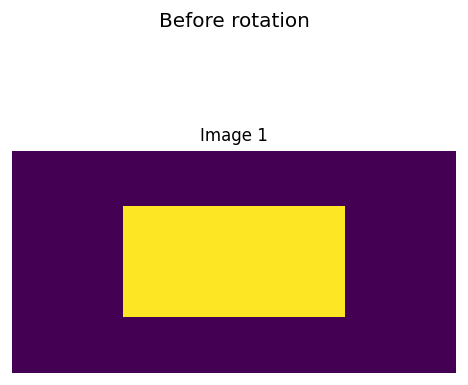

In [4]:
rect = np.zeros((64, 128), dtype=np.float32)
rect[16:48, 32:96] = 1.0
w2 = Show2D(rect, title="Before rotation", cmap="viridis")
w2

In [5]:
w2.rotate(0, 90)
w2.summary()

Before rotation
════════════════════════════════
Image:    128×64
Data:     min=0  max=1  mean=0.25
Display:  viridis | manual contrast | linear
Rotated:  #0=90°


## Gallery with mixed orientations
Rotating a non-square image changes its dimensions.
All gallery images are center-padded to the largest shape.

In [ ]:
tall = np.random.default_rng(0).random((200, 100)).astype(np.float32)
wide = np.random.default_rng(1).random((100, 200)).astype(np.float32)
sq = np.random.default_rng(2).random((150, 150)).astype(np.float32)
w3 = Show2D([tall, wide, sq], labels=["Tall", "Wide", "Square"], title="Mixed shapes", ncols=3)
w3.rotate(0, 90)  # tall → wide after rotation, triggers padding
w3

## State persistence
Rotations survive `state_dict()` / `state=` roundtrip.

In [ ]:
sd = w3.state_dict()
print(f"Saved rotations: {sd['image_rotations']}")
w4 = Show2D([tall, wide, sq], labels=["Tall", "Wide", "Square"], state=sd)
print(f"Restored rotations: {w4.image_rotations}")